Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/uberesult/skyrmion/20260503_02
Device: cpu
Project root content: ['Notebooks', 'data', 'Magnetisation']
Reading from: /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/ubermag_data/skyrmion/20260430_03
Bz_NV shape: (256, 256)
Mz_true shape: (256, 256)
Bz_NV range (mT): 96.345 ~ 363.865
Mz_true range (A/m): -580000.0 ~ 580000.0
Bz_NV_input range (T): -0.0001 ~ 2.652853539209866e-06
[[2.65285354e-06 2.63780863e-06 2.61045643e-06 ... 2.61045643e-06
  2.63780863e-06 2.65285354e-06]
 [2.63780863e-06 2.62273105e-06 2.59531904e-06 ... 2.59531904e-06
  2.62273105e-06 2.63780863e-06]
 [2.61045643e-06 2.59531904e-06 2.56779751e-06 ... 2.56779751e-06
  2.59531904e-06 2.61045643e-06]
 ...
 [2.61045643e-06 2.59531904e-06 2.56779751e-06 ... 2.56779751e-06
  2.59531904e-06 2.61

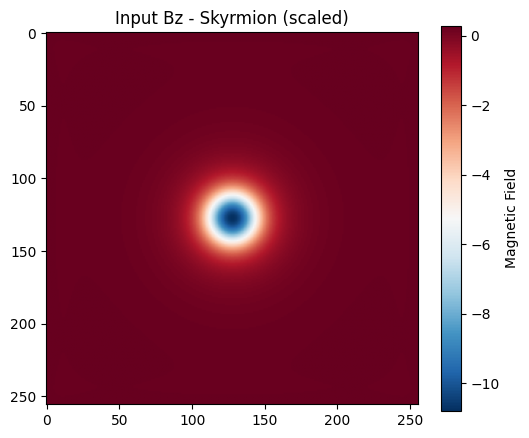

100%|██████████| 500/500 [01:15<00:00,  6.66it/s]


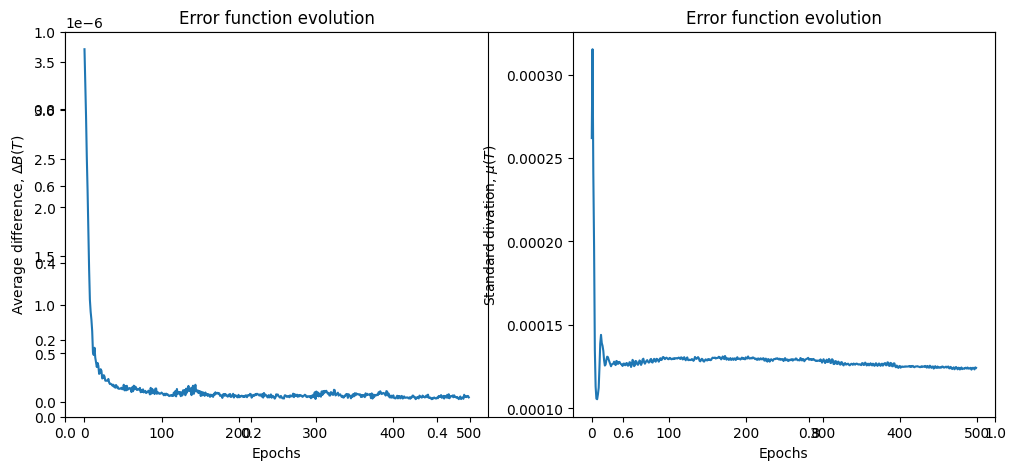

Final MagnetisationMap shape: (256, 256)
Final ReconstructedBnv shape: (256, 256)


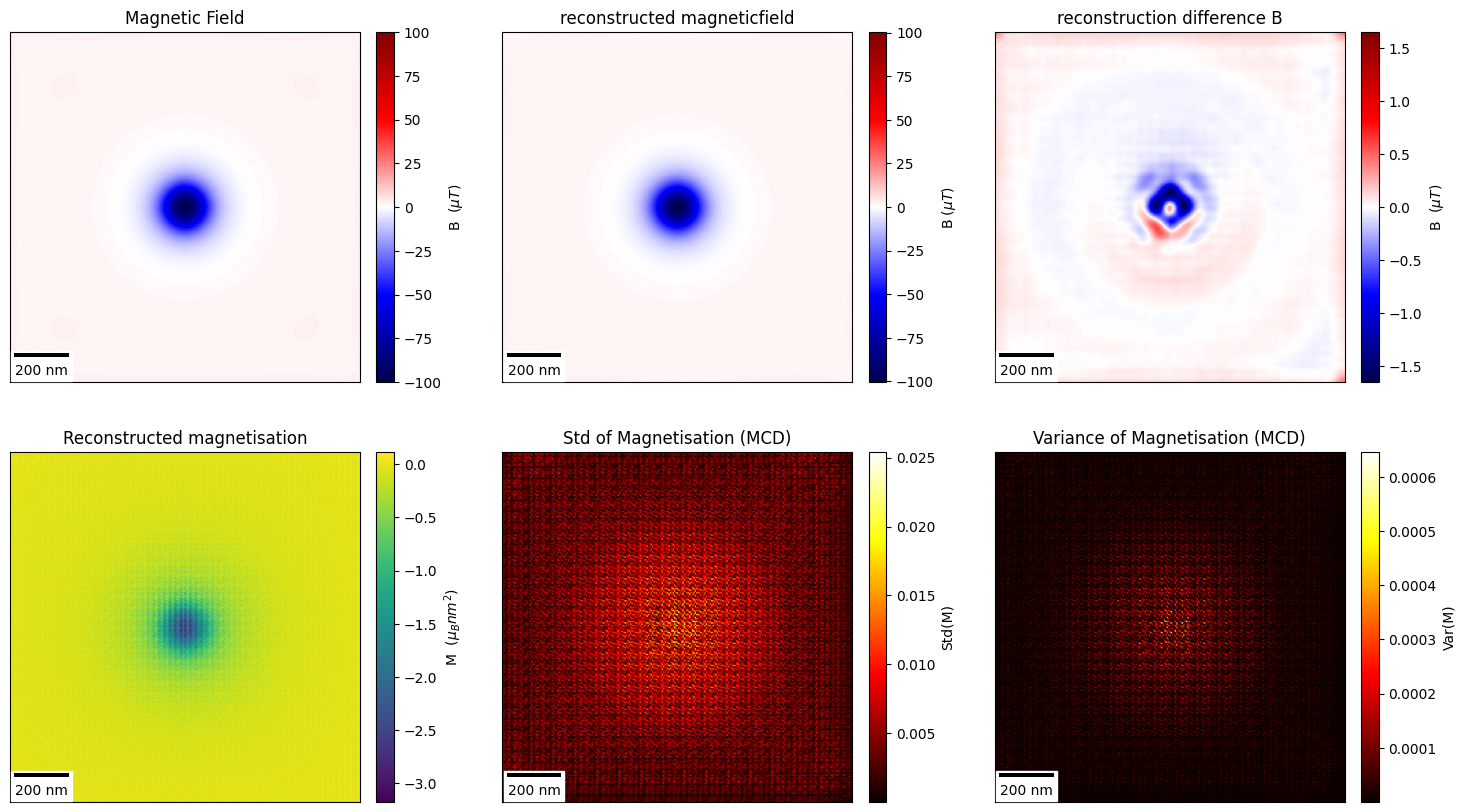

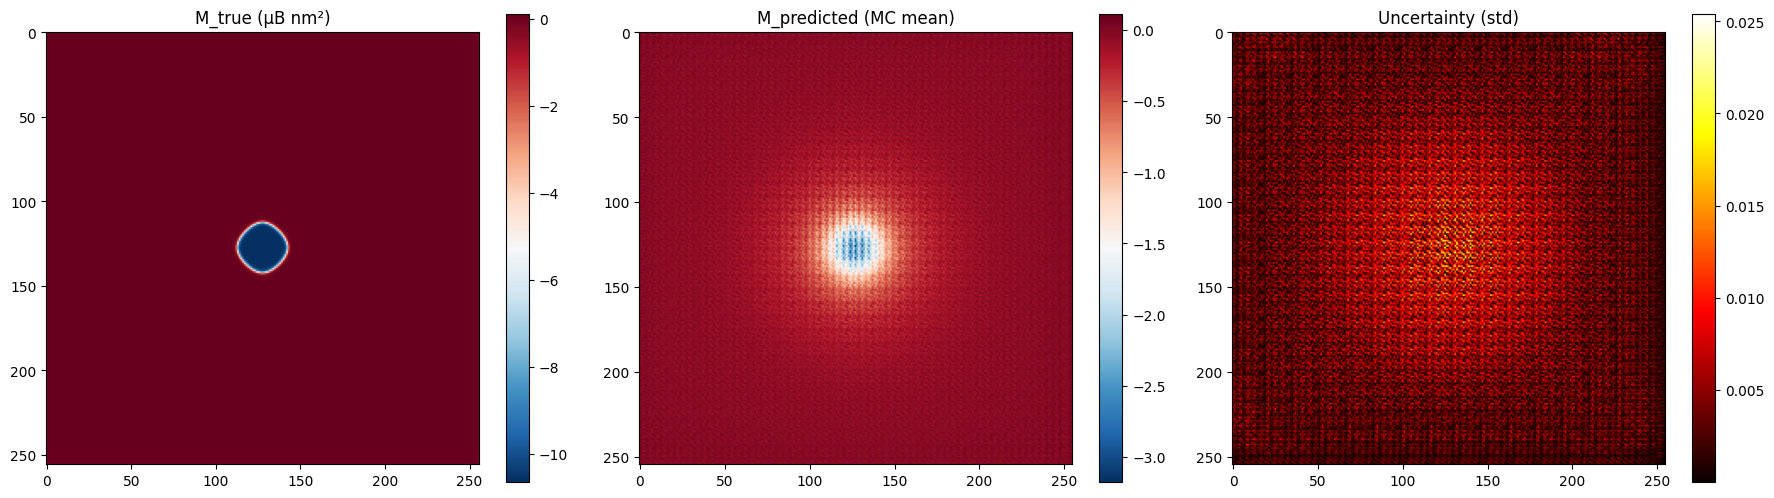

M_true range (μB nm²): -10.6429 ~ 0.1103
M_predicted range: -3.1768 ~ 0.1145
M_std range: 1.2493062e-05 ~ 0.025410105
Difference factor: 0.0
scale_factor used: 2606.0680737214525

All results saved to: /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/uberesult/skyrmion/20260503_02
Bz_NV_centered range (T): -0.26060680737214525 ~ 0.0069135169127937934
Mz_true_centered range (A/m): -1148106.5302161837 ~ 11893.451974348049
Mz_true_converted range (μB nm²): -10.642947535104021 ~ 0.1102522998022064


In [3]:
# ======================================================
# Cell 1: 安装和设置
# ======================================================
!pip install matplotlib_scalebar
from google.colab import drive
drive.mount('/content/drive')

import sys, os, glob
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from datetime import datetime

base_save = '/content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/uberesult/skyrmion'

date_str = datetime.now().strftime("%Y%m%d")
idx = 1
while os.path.exists(os.path.join(base_save, f"{date_str}_{idx:02d}")):
    idx += 1

save_dir = os.path.join(base_save, f"{date_str}_{idx:02d}")
os.makedirs(save_dir, exist_ok=True)
print("Save directory:", save_dir)

PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/2D"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from Magnetisation.Propagator import Propagator
from Magnetisation.Generator import generator_CNN
from Magnetisation.Train import Magnetisation_CNN_training

if not hasattr(np, "int"):
    np.int = int

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("Project root content:", os.listdir(PROJECT_ROOT))

# ======================================================
# Cell 2: 自动读取最新 ubermag skyrmion 数据
# ======================================================
skyrmion_base = '/content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/ubermag_data/skyrmion'

all_dirs = sorted(glob.glob(os.path.join(skyrmion_base, "*")))
latest_dir = all_dirs[-1]
print("Reading from:", latest_dir)

Bz_NV = np.load(os.path.join(latest_dir, "Bz_NV_skyrmion.npy"))
Mz_true = np.load(os.path.join(latest_dir, "Mz_true_skyrmion.npy"))

print("Bz_NV shape:", Bz_NV.shape)
print("Mz_true shape:", Mz_true.shape)
print("Bz_NV range (mT):", round(Bz_NV.min()*1e3, 3), "~", round(Bz_NV.max()*1e3, 3))
print("Mz_true range (A/m):", round(Mz_true.min(), 1), "~", round(Mz_true.max(), 1))

# ======================================================
# Cell 3: 设置 PropagationOptions + PROP
# ======================================================
unit_conversion = 1e-18 / 9.27e-24  # = 107874

# 缩放 Bz_NV 让 MagneticFieldExtended 和实验数据量级一致
# 实验数据原始值约 ±1e-4 T → 乘以 unit_conversion → ±10
# ubermag 数据约 0.1~0.4 T → 需要先缩放到 ±1e-4 T 量级
Bz_NV_mean = Bz_NV.mean()
Bz_NV_centered = Bz_NV - Bz_NV_mean        # 去掉均值，只保留变化部分
scale_factor = np.max(np.abs(Bz_NV_centered)) / 1e-4  # 缩放到 ±1e-4 T 量级
Bz_NV_input = Bz_NV_centered / scale_factor

print("Bz_NV_input range (T):", Bz_NV_input.min(), "~", Bz_NV_input.max())

PropagationOptions = dict()
PropagationOptions['PixelSize'] = 5e-9
PropagationOptions['ImageShape'] = 256
PropagationOptions['NV'] = dict()
PropagationOptions['NV']['FindTheta'] = False
PropagationOptions['NV']['Theta'] = 0
PropagationOptions['NV']['FindPhi'] = False
PropagationOptions['NV']['Phi'] = 0
PropagationOptions['NV']['Height'] = 50e-9
PropagationOptions['Magnetisation'] = dict()
PropagationOptions['Magnetisation']['FindTheta'] = False
PropagationOptions['Magnetisation']['Theta'] = 0
PropagationOptions['Magnetisation']['FindPhi'] = False
PropagationOptions['Magnetisation']['Phi'] = 0
PropagationOptions['FFT'] = dict()
PropagationOptions["FFT"]["PaddingFactor"] = 4
PropagationOptions["FFT"]["performPadding"] = False
PropagationOptions["FFT"]["PaddingMode"] = 'constant'
PropagationOptions['FFT']['Extended'] = False
PropagationOptions['FFT']['Extention'] = 100
PropagationOptions['FFT']['Filter'] = dict()
PropagationOptions['FFT']['Filter']['useHanning'] = True
PropagationOptions['FFT']['Filter']['useHighCutoff'] = False
PropagationOptions['FFT']['Filter']['useLowCutoff'] = False
PropagationOptions['FFT']['Filter']['LambdaHighCutoff'] = 100e-9
PropagationOptions['FFT']['Filter']['LambdaLowCutoff'] = 7e-06

PROP = Propagator(PropagationOptions, Bz_NV_input, PropagationOptions['ImageShape'])

print("PROP mask unique values:", np.unique(PROP.Mask))
print("PROP MagneticFieldExtended range:",
      round(PROP.MagneticFieldExtended.min(), 4), "~",
      round(PROP.MagneticFieldExtended.max(), 4))

plt.figure(figsize=(6, 5))
plt.imshow(PROP.MagneticFieldExtended, cmap='RdBu_r')
plt.colorbar(label='Magnetic Field')
plt.title('Input Bz - Skyrmion (scaled)')
plt.savefig(os.path.join(save_dir, '1_input_Bz.png'), dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# Cell 4: 固定seed, 训练网络
# ======================================================
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

Generator = generator_CNN(Size=1, ImageSize=PROP.options['ImageShape']).to(device)

ML_options = dict()
ML_options['mlp'] = False
ML_options['LossFunction'] = 'L1'
ML_options['Epochs'] = 500
ML_options['Magnetization'] = None
ML_options['PositiveMagnetisationOnly'] = False
ML_options['PrintLossValue'] = False
ML_options['IntegerOnly'] = False

CNN_training = Magnetisation_CNN_training(device, Generator, PROP, ML_options)
bnv_cnn = CNN_training.train_cnn(**ML_options)
plt.savefig(os.path.join(save_dir, '2_training_loss.png'), dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# Cell 5: 重建结果（包含 MC Dropout uncertainty）
# ======================================================
Results = CNN_training.extract_results(plotResults=True)
plt.savefig(os.path.join(save_dir, '3_reconstruction_results.png'), dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# Cell 6: 对比 M_true vs M_predicted
# ======================================================
unit_conversion = 1e-18 / 9.27e-24
#Mz_true_converted = Mz_true / unit_conversion
Mz_true_centered = Mz_true - Mz_true.mean()
Mz_true_converted = Mz_true_centered / unit_conversion

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(Mz_true_converted, cmap='RdBu_r')
axes[0].set_title('M_true (μB nm²)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(Results['Magnetisation'], cmap='RdBu_r')
axes[1].set_title('M_predicted (MC mean)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(Results['Magnetisation Std'], cmap='hot')
axes[2].set_title('Uncertainty (std)')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig(os.path.join(save_dir, '4_Mtrue_vs_Mpredicted.png'), dpi=300, bbox_inches='tight')
plt.show()

print("M_true range (μB nm²):", round(Mz_true_converted.min(), 4), "~", round(Mz_true_converted.max(), 4))
print("M_predicted range:", round(Results['Magnetisation'].min(), 4), "~", round(Results['Magnetisation'].max(), 4))
print("M_std range:", Results['Magnetisation Std'].min(), "~", Results['Magnetisation Std'].max())
print("Difference factor:", round(abs(Mz_true_converted.mean()) / abs(Results['Magnetisation'].mean()), 2))
print("scale_factor used:", scale_factor)
print("\nAll results saved to:", save_dir)

print("Bz_NV_centered range (T):", Bz_NV_centered.min(), "~", Bz_NV_centered.max())
print("Mz_true_centered range (A/m):", Mz_true_centered.min(), "~", Mz_true_centered.max())
print("Mz_true_converted range (μB nm²):", Mz_true_converted.min(), "~", Mz_true_converted.max())